# Step 1 — Import Required Libraries

Python provides many libraries that simplify data manipulation, visualisation, and machine learning.

The following libraries will be used throughout this notebook.

In [ ]:
# ===============================
# Import Required Libraries
# ===============================

# Data manipulation
import pandas as pd
import numpy as np

# Data visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Improve appearance of plots
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [ ]:
# ===============================
# Load datasets
# ===============================

hr_df = pd.read_csv("/content/hr_op-2.csv")

personal_df = pd.read_excel("/content/personal_op.xlsx")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [ ]:
# Display dimensions of both datasets

print("HR Dataset Shape:")
print(hr_df.shape)

print("\nPeople Experience Dataset Shape:")
print(personal_df.shape)

HR Dataset Shape:
(5000, 13)

People Experience Dataset Shape:
(5000, 8)


In [ ]:
# Display first five rows

print("HR Dataset")
display(hr_df.head())

print("People Experience Dataset")
display(personal_df.head())

HR Dataset


,employee_id,job_role,department,tenure_years,monthly_income,overtime_hours,travel_frequency,job_satisfaction,manager_rating,training_hours,work_life_balance_score,remote_friendly_role,attrition
0,10001,Operations,HR,0.77,4731.09,34.4,Frequent,1,5,4,3,0,0
1,10002,Manager,Technology,8.04,3601.76,9.2,NaN,2,2,23,5,1,0
2,10003,HR,Consulting,7.17,4389.74,24.9,Frequent,3,5,19,3,0,1
3,10004,Operations,Technology,4.56,4575.93,25.9,Occasional,4,5,36,2,0,0
4,10005,Developer,Operations,0.06,2791.37,17.2,NaN,1,2,30,1,0,1


People Experience Dataset


,employee_id,age,gender,ethnicity,marital_status,disability_status,commute_distance_km,attrition
0,10001,34,Male,Other,Single,NaN,6.0,0
1,10002,33,Female,Other,Widowed,NaN,21.7,0
2,10003,49,Male,White,Widowed,NaN,12.1,1
3,10004,62,Male,Mixed,Married,NaN,18.4,0
4,10005,21,Female,Asian,Married,NaN,5.6,1


In [ ]:
# Display column names

print("HR Dataset Columns")
print(hr_df.columns)

print("\nPeople Experience Dataset Columns")
print(personal_df.columns)

HR Dataset Columns
Index(['employee_id', 'job_role', 'department', 'tenure_years',
       'monthly_income', 'overtime_hours', 'travel_frequency',
       'job_satisfaction', 'manager_rating', 'training_hours',
       'work_life_balance_score', 'remote_friendly_role', 'attrition'],
      dtype='object')

People Experience Dataset Columns
Index(['employee_id', 'age', 'gender', 'ethnicity', 'marital_status',
       'disability_status', 'commute_distance_km', 'attrition'],
      dtype='object')


In [ ]:
# Display data types

print("HR Dataset Information")

display(hr_df.info())

print("\nPeople Experience Dataset Information")

display(personal_df.info())

HR Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   employee_id              5000 non-null   int64  
 1   job_role                 5000 non-null   object 
 2   department               5000 non-null   object 
 3   tenure_years             5000 non-null   float64
 4   monthly_income           5000 non-null   float64
 5   overtime_hours           5000 non-null   float64
 6   travel_frequency         3383 non-null   object 
 7   job_satisfaction         5000 non-null   int64  
 8   manager_rating           5000 non-null   int64  
 9   training_hours           5000 non-null   int64  
 10  work_life_balance_score  5000 non-null   int64  
 11  remote_friendly_role     5000 non-null   int64  
 12  attrition                5000 non-null   int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 507.9+

None


People Experience Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   employee_id          5000 non-null   int64  
 1   age                  5000 non-null   int64  
 2   gender               5000 non-null   object 
 3   ethnicity            5000 non-null   object 
 4   marital_status       5000 non-null   object 
 5   disability_status    760 non-null    object 
 6   commute_distance_km  5000 non-null   float64
 7   attrition            5000 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 312.6+ KB


None

# Step 3 — Merge and Validate the Datasets

Both datasets contain information about the same employees and are linked through the **ID** column. Before analysis, the datasets are merged into a single dataframe and validated to ensure data integrity.

Validation includes:

- Checking duplicate employee IDs
- Confirming successful merge
- Examining missing values
- Reviewing data types

In [ ]:
# ===============================
# Merge datasets on Employee ID
# ===============================

employee_df = pd.merge(
    hr_df,
    personal_df,
    on="employee_id",
    how="inner"
)

print("Merged dataset shape:", employee_df.shape)

employee_df.head()

Merged dataset shape: (5000, 20)


,employee_id,job_role,department,tenure_years,monthly_income,overtime_hours,travel_frequency,job_satisfaction,manager_rating,training_hours,work_life_balance_score,remote_friendly_role,attrition_x,age,gender,ethnicity,marital_status,disability_status,commute_distance_km,attrition_y
0,10001,Operations,HR,0.77,4731.09,34.4,Frequent,1,5,4,3,0,0,34,Male,Other,Single,NaN,6.0,0
1,10002,Manager,Technology,8.04,3601.76,9.2,NaN,2,2,23,5,1,0,33,Female,Other,Widowed,NaN,21.7,0
2,10003,HR,Consulting,7.17,4389.74,24.9,Frequent,3,5,19,3,0,1,49,Male,White,Widowed,NaN,12.1,1
3,10004,Operations,Technology,4.56,4575.93,25.9,Occasional,4,5,36,2,0,0,62,Male,Mixed,Married,NaN,18.4,0
4,10005,Developer,Operations,0.06,2791.37,17.2,NaN,1,2,30,1,0,1,21,Female,Asian,Married,NaN,5.6,1


In [ ]:
# Check duplicate employee IDs

duplicate_ids = employee_df["employee_id"].duplicated().sum()

print(f"Duplicate IDs: {duplicate_ids}")

Duplicate IDs: 0


In [ ]:
# Missing values

missing_values = employee_df.isnull().sum()

missing_values[missing_values > 0]

,0
travel_frequency,1617
disability_status,4240


In [ ]:
# Percentage of missing values

missing_percent = (
    employee_df.isnull().sum() /
    len(employee_df)
) * 100

missing_percent = missing_percent.sort_values(ascending=False)

missing_percent[missing_percent > 0]

,0
disability_status,84.80
travel_frequency,32.34


In [ ]:
# Percentage of missing values

missing_percent = (
    employee_df.isnull().sum() /
    len(employee_df)
) * 100

missing_percent = missing_percent.sort_values(ascending=False)

missing_percent[missing_percent > 0]

,0
disability_status,84.80
travel_frequency,32.34


In [ ]:
employee_df.dtypes

,0
employee_id,int64
job_role,object
department,object
tenure_years,float64
monthly_income,float64
overtime_hours,float64
travel_frequency,object
job_satisfaction,int64
manager_rating,int64
training_hours,int64


In [ ]:
#Summary Statistics
employee_df.describe(include="all")

,employee_id,job_role,department,tenure_years,monthly_income,overtime_hours,travel_frequency,job_satisfaction,manager_rating,training_hours,work_life_balance_score,remote_friendly_role,attrition_x,age,gender,ethnicity,marital_status,disability_status,commute_distance_km,attrition_y
count,5000.000000,5000,5000,5000.000000,5000.000000,5000.000000,3383,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000,5000,5000,760,5000.000000,5000.000000
unique,NaN,8,6,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,6,6,4,NaN,NaN
top,NaN,Manager,Technology,NaN,NaN,NaN,Occasional,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Other,White,Single,Mental,NaN,NaN
freq,NaN,747,1065,NaN,NaN,NaN,1723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1696,1048,1298,353,NaN,NaN
mean,12500.500000,NaN,NaN,2.912652,4013.316072,20.127300,NaN,2.996000,2.990400,29.333800,3.004600,0.40280,0.428600,41.051800,NaN,NaN,NaN,NaN,14.915640,0.428600
std,1443.520003,NaN,NaN,2.865456,1170.102395,14.136749,NaN,1.399849,1.419546,17.412151,1.422597,0.49051,0.494925,13.335662,NaN,NaN,NaN,NaN,8.555496,0.494925
min,10001.000000,NaN,NaN,0.000000,1500.000000,0.100000,NaN,1.000000,1.000000,0.000000,1.000000,0.00000,0.000000,18.000000,NaN,NaN,NaN,NaN,0.700000,0.000000
25%,11250.750000,NaN,NaN,0.870000,3207.612500,9.500000,NaN,2.000000,2.000000,14.000000,2.000000,0.00000,0.000000,29.750000,NaN,NaN,NaN,NaN,8.600000,0.000000
50%,12500.500000,NaN,NaN,2.030000,4004.070000,16.900000,NaN,3.000000,3.000000,29.000000,3.000000,0.00000,0.000000,41.000000,NaN,NaN,NaN,NaN,13.400000,0.000000
75%,13750.250000,NaN,NaN,4.020000,4794.770000,27.325000,NaN,4.000000,4.000000,44.000000,4.000000,1.00000,1.000000,52.000000,NaN,NaN,NaN,NaN,19.400000,1.000000


In [ ]:
#Dataset information
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   employee_id              5000 non-null   int64  
 1   job_role                 5000 non-null   object 
 2   department               5000 non-null   object 
 3   tenure_years             5000 non-null   float64
 4   monthly_income           5000 non-null   float64
 5   overtime_hours           5000 non-null   float64
 6   travel_frequency         3383 non-null   object 
 7   job_satisfaction         5000 non-null   int64  
 8   manager_rating           5000 non-null   int64  
 9   training_hours           5000 non-null   int64  
 10  work_life_balance_score  5000 non-null   int64  
 11  remote_friendly_role     5000 non-null   int64  
 12  attrition_x              5000 non-null   int64  
 13  age                      5000 non-null   int64  
 14  gender                  

In [ ]:
# View unique values for categorical variables

categorical_cols = employee_df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("="*50)
    print(col)
    print(employee_df[col].value_counts())

job_role
job_role
Manager       747
HR            738
Consultant    735
Finance       711
Analyst       694
Developer     691
Operations    683
F               1
Name: count, dtype: int64
department
department
Technology    1065
Operations    1004
Consulting     984
HR             973
Finance        973
C                1
Name: count, dtype: int64
travel_frequency
travel_frequency
Occasional    1723
Frequent      1656
0                3
F                1
Name: count, dtype: int64
gender
gender
Other     1696
Male      1665
Female    1638
O            1
Name: count, dtype: int64
ethnicity
ethnicity
White    1048
Asian    1013
Other     998
Black     983
Mixed     957
W           1
Name: count, dtype: int64
marital_status
marital_status
Single      1298
Married     1258
Widowed     1238
Divorced    1204
S              1
W              1
Name: count, dtype: int64
disability_status
disability_status
Mental      353
Physical    266
Other       139
0             2
Name: count, dtype: int64


In [ ]:
numeric_cols = employee_df.select_dtypes(include=np.number).columns

employee_df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
employee_id,5000.0,12500.500000,1443.520003,10001.0,11250.7500,12500.50,13750.250,15000.00
tenure_years,5000.0,2.912652,2.865456,0.0,0.8700,2.03,4.020,24.08
monthly_income,5000.0,4013.316072,1170.102395,1500.0,3207.6125,4004.07,4794.770,8114.69
overtime_hours,5000.0,20.127300,14.136749,0.1,9.5000,16.90,27.325,136.90
job_satisfaction,5000.0,2.996000,1.399849,1.0,2.0000,3.00,4.000,5.00
manager_rating,5000.0,2.990400,1.419546,1.0,2.0000,3.00,4.000,5.00
training_hours,5000.0,29.333800,17.412151,0.0,14.0000,29.00,44.000,59.00
work_life_balance_score,5000.0,3.004600,1.422597,1.0,2.0000,3.00,4.000,5.00
remote_friendly_role,5000.0,0.402800,0.490510,0.0,0.0000,0.00,1.000,1.00
attrition_x,5000.0,0.428600,0.494925,0.0,0.0000,0.00,1.000,1.00


Data Cleaning
# Remove duplicates

In [ ]:
employee_df = employee_df.drop_duplicates()

print("Shape after removing duplicates:")
print(employee_df.shape)

Shape after removing duplicates:
(5000, 20)


#Handle missing values

In [ ]:
# Handle missing and invalid categorical values

cat_cols = employee_df.select_dtypes(include="object").columns

# Treat unexpected single-character/numeric codes as missing
invalid_values = ["0", "F", "C", "O", "W", "S"]

for col in cat_cols:
    employee_df[col] = employee_df[col].replace(invalid_values, np.nan)

# Preserve missing categorical information rather than assigning
# all missing values to the most common category
employee_df[cat_cols] = employee_df[cat_cols].fillna("Not Reported")

In [ ]:
#verify no missing values remain

employee_df.isnull().sum()

,0
employee_id,0
job_role,0
department,0
tenure_years,0
monthly_income,0
overtime_hours,0
travel_frequency,0
job_satisfaction,0
manager_rating,0
training_hours,0


# Check outliers (boxplots)

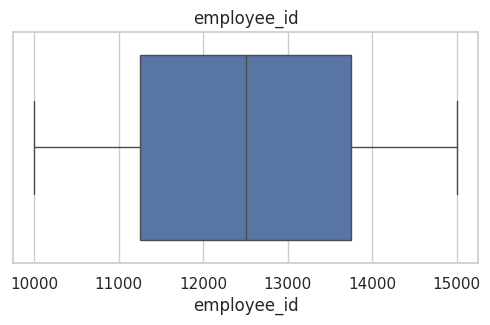

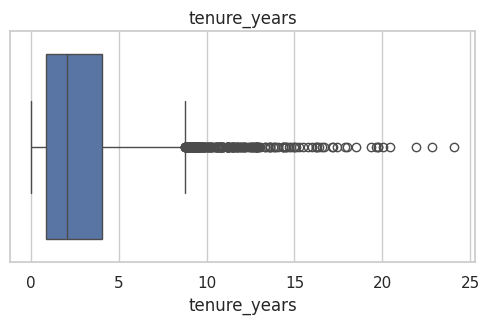

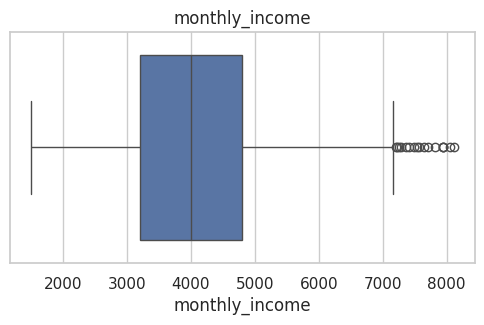

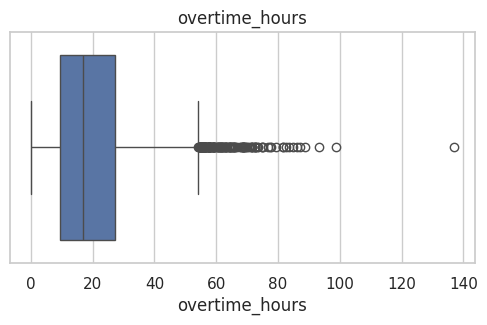

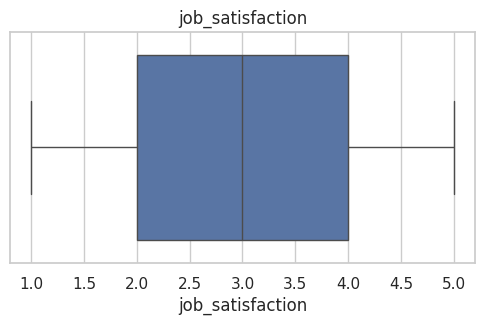

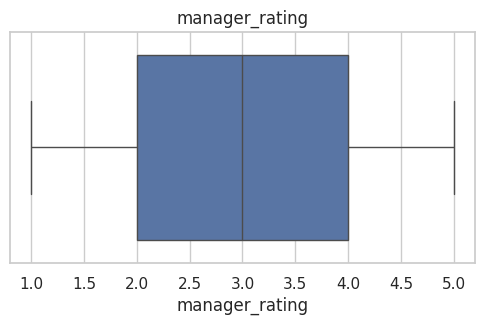

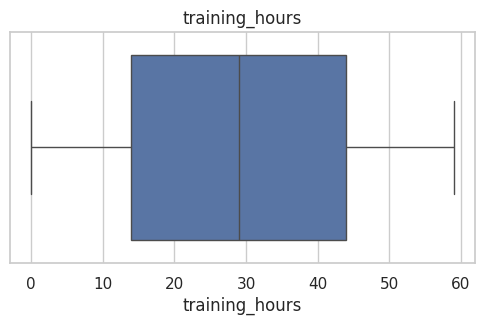

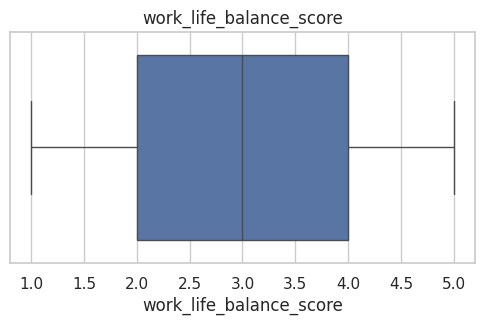

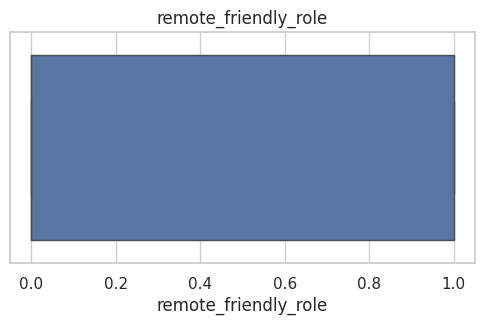

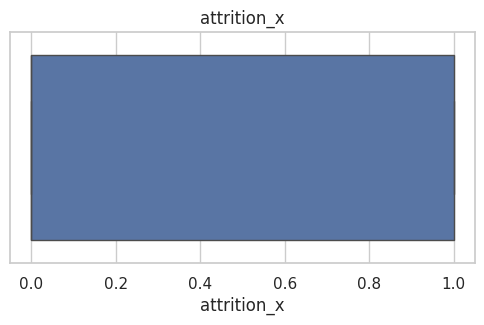

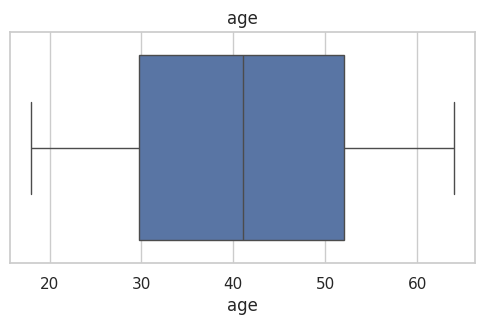

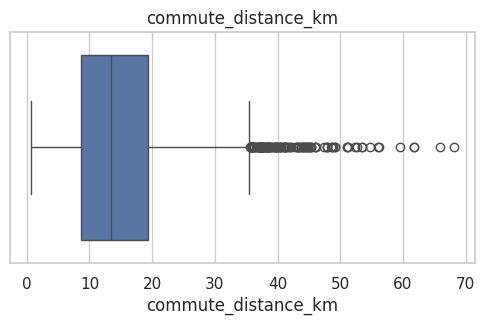

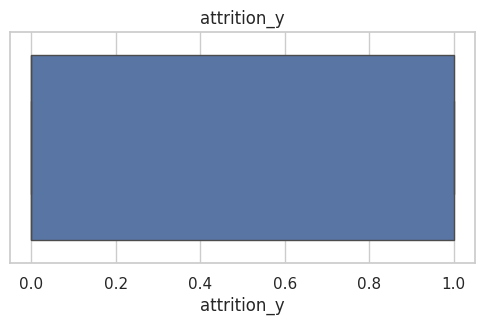

In [ ]:
numeric_cols = employee_df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=employee_df[col])
    plt.title(col)
    plt.show()

# Final cleaned dataset

In [ ]:
employee_df.head()

,employee_id,job_role,department,tenure_years,monthly_income,overtime_hours,travel_frequency,job_satisfaction,manager_rating,training_hours,work_life_balance_score,remote_friendly_role,attrition_x,age,gender,ethnicity,marital_status,disability_status,commute_distance_km,attrition_y
0,10001,Operations,HR,0.77,4731.09,34.4,Frequent,1,5,4,3,0,0,34,Male,Other,Single,Not Reported,6.0,0
1,10002,Manager,Technology,8.04,3601.76,9.2,Not Reported,2,2,23,5,1,0,33,Female,Other,Widowed,Not Reported,21.7,0
2,10003,HR,Consulting,7.17,4389.74,24.9,Frequent,3,5,19,3,0,1,49,Male,White,Widowed,Not Reported,12.1,1
3,10004,Operations,Technology,4.56,4575.93,25.9,Occasional,4,5,36,2,0,0,62,Male,Mixed,Married,Not Reported,18.4,0
4,10005,Developer,Operations,0.06,2791.37,17.2,Not Reported,1,2,30,1,0,1,21,Female,Asian,Married,Not Reported,5.6,1


# Step 4 — Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is conducted to better understand the employee data before building predictive models.

The objectives of EDA are to:

- Understand workforce composition
- Identify patterns and trends
- Detect relationships between variables
- Identify potential predictors of employee attrition
- Support the selection of appropriate machine learning models

The following analyses and visualisations are produced based on the business requirements provided by Novora.

**1. Distribution of Employees by Department**

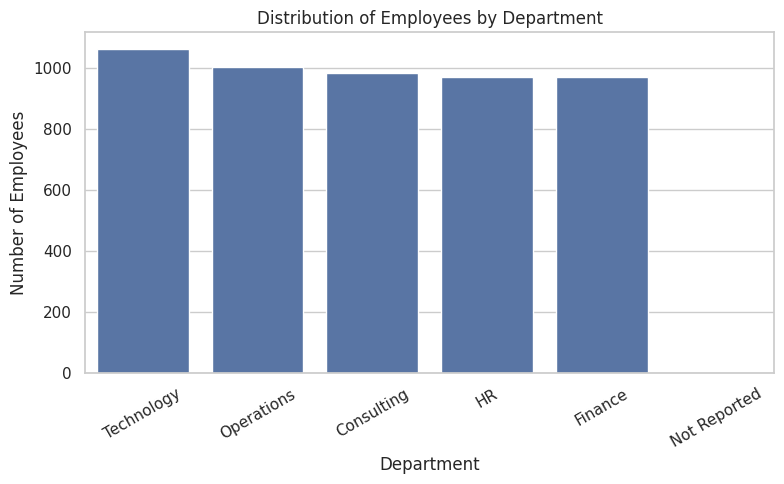

In [ ]:
# ===============================
# Distribution of Employees by Department
# ===============================

plt.figure(figsize=(8,5))

sns.countplot(
    data=employee_df,
    x="department",
    order=employee_df["department"].value_counts().index
)

plt.title("Distribution of Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

**Distribution of Employees by Job Role**

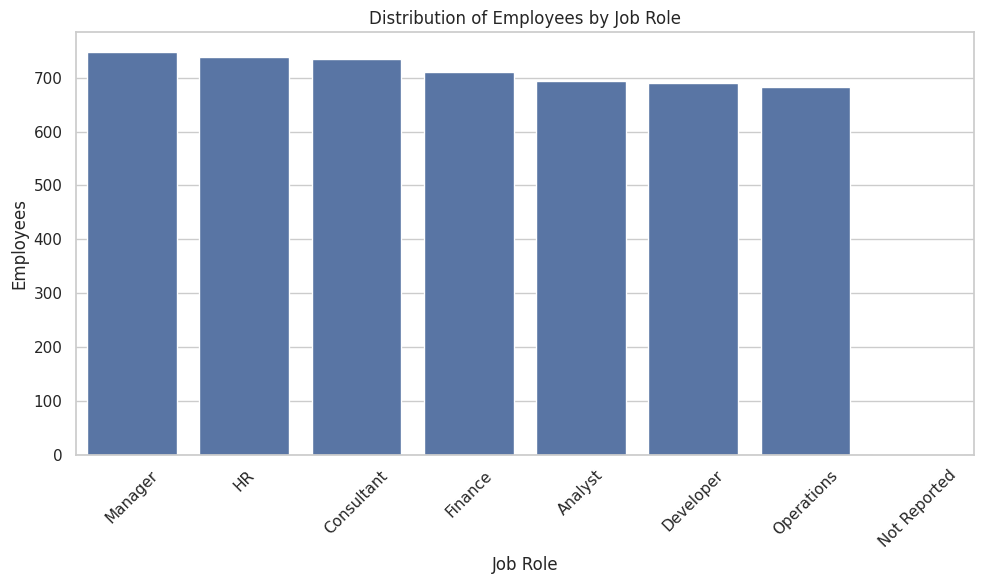

In [ ]:
# ===============================
# Distribution of Employees by Job Role
# ===============================

plt.figure(figsize=(10,6))

sns.countplot(
    data=employee_df,
    x="job_role",
    order=employee_df["job_role"].value_counts().index
)

plt.title("Distribution of Employees by Job Role")

plt.xlabel("Job Role")

plt.ylabel("Employees")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**# Average Employee Tenure**

In [ ]:
# ===============================
# Average Employee Tenure
# ===============================

average_tenure = employee_df["tenure_years"].mean()

print(f"Average Tenure: {average_tenure:.2f} years")

Average Tenure: 2.91 years


**4. Average Monthly Income by Department**

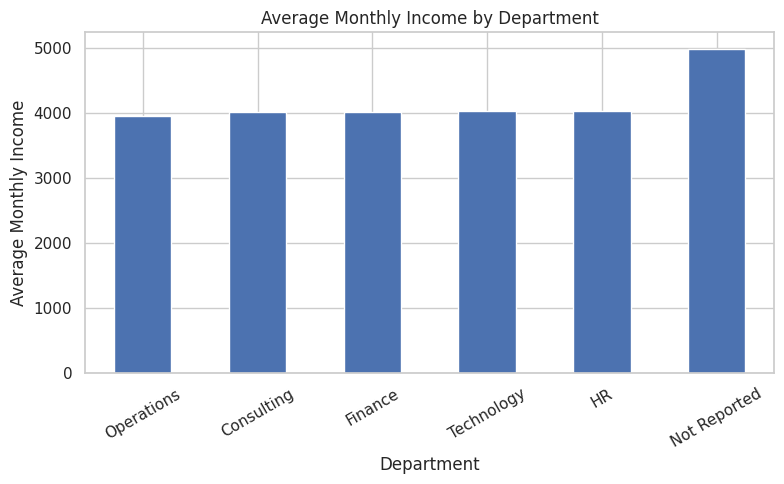

In [ ]:
# ===============================
# Average Monthly Income by Department
# ===============================

income_department = employee_df.groupby("department")["monthly_income"].mean().sort_values()
plt.figure(figsize=(8,5))

income_department.plot(kind="bar")

plt.title("Average Monthly Income by Department")
plt.xlabel("Department")
plt.ylabel("Average Monthly Income")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**5. Average Overtime by Attrition**

Average overtime hours by attrition:
attrition_x
0    18.302275
1    22.560383
Name: overtime_hours, dtype: float64


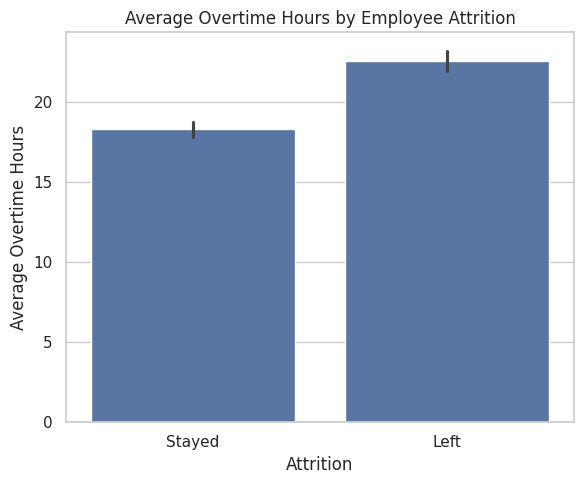

In [ ]:
# ==========================================
# Average Overtime Hours by Attrition
# ==========================================

overtime_by_attrition = (
    employee_df.groupby("attrition_x")["overtime_hours"]
    .mean()
)

print("Average overtime hours by attrition:")
print(overtime_by_attrition)

plt.figure(figsize=(6, 5))

sns.barplot(
    data=employee_df,
    x="attrition_x",
    y="overtime_hours"
)

plt.title("Average Overtime Hours by Employee Attrition")
plt.xlabel("Attrition")
plt.ylabel("Average Overtime Hours")

plt.xticks([0, 1], ["Stayed", "Left"])

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Check consistency of the two attrition columns
# ==========================================

print("attrition_x value counts:")
print(employee_df["attrition_x"].value_counts())

print("\nattrition_y value counts:")
print(employee_df["attrition_y"].value_counts())

# Check whether the two attrition columns contain identical values
attrition_match = (
    employee_df["attrition_x"] == employee_df["attrition_y"]
).all()

print("\nDo both attrition columns match?", attrition_match)

attrition_x value counts:
attrition_x
0    2857
1    2143
Name: count, dtype: int64

attrition_y value counts:
attrition_y
0    2857
1    2143
Name: count, dtype: int64

Do both attrition columns match? True


In [ ]:
# ==========================================
# Create the final attrition target variable
# ==========================================

# Both source columns have been verified to match.
# We use attrition_x as the single target variable.

employee_df["attrition"] = employee_df["attrition_x"]

print("Final attrition column created successfully.")
print(employee_df["attrition"].value_counts())

print("\nAttrition proportions:")
print(employee_df["attrition"].value_counts(normalize=True))

Final attrition column created successfully.
attrition
0    2857
1    2143
Name: count, dtype: int64

Attrition proportions:
attrition
0    0.5714
1    0.4286
Name: proportion, dtype: float64


**6. Monthly Income Distribution**

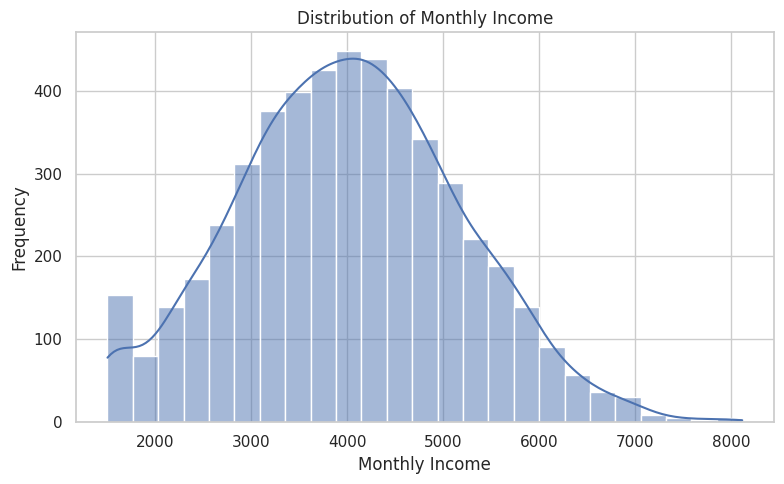

In [ ]:
# ===============================
# Distribution of Monthly Income
# ===============================

plt.figure(figsize=(8,5))

sns.histplot(
    employee_df["monthly_income"],
    bins=25,
    kde=True
)

plt.title("Distribution of Monthly Income")

plt.xlabel("Monthly Income")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

**7. Distribution of Ethnicity**

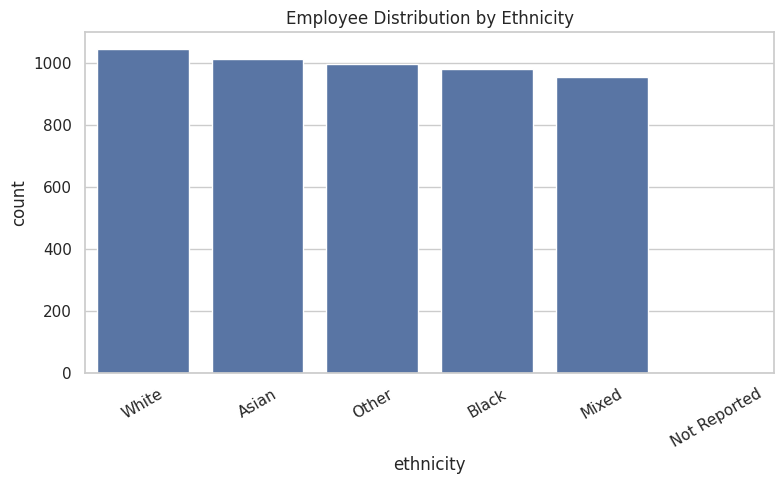

In [ ]:
# ===============================
# Distribution of Ethnicity
# ===============================

plt.figure(figsize=(8,5))

sns.countplot(
    data=employee_df,
    x="ethnicity",
    order=employee_df["ethnicity"].value_counts().index
)

plt.title("Employee Distribution by Ethnicity")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

**8. Average Income by Gender**

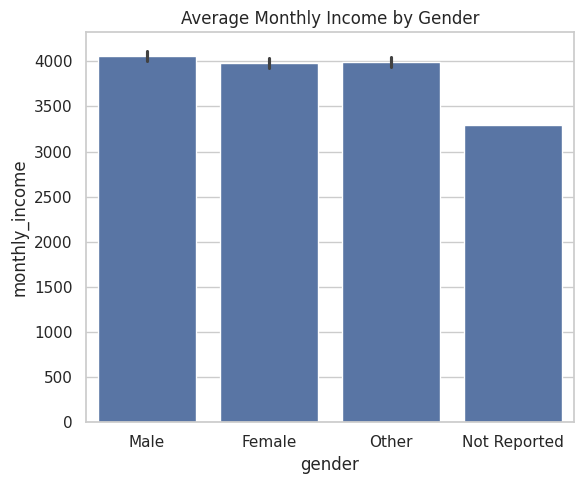

In [ ]:
# ===============================
# Average Monthly Income by Gender
# ===============================

plt.figure(figsize=(6,5))

sns.barplot(
    data=employee_df,
    x="gender",
    y="monthly_income"
)

plt.title("Average Monthly Income by Gender")

plt.tight_layout()

plt.show()

**Optional Analysis 1 — Marital Status**

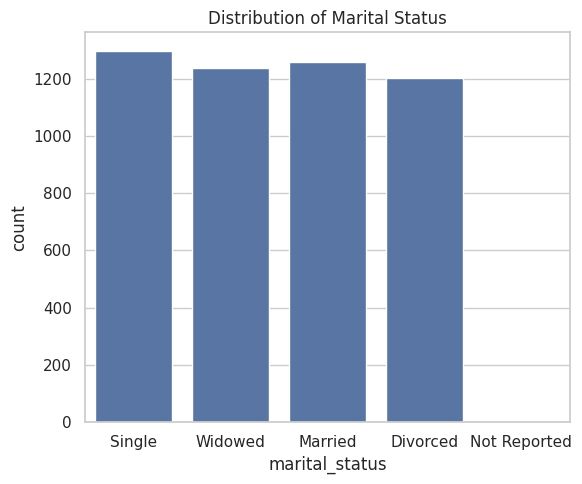

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=employee_df,
    x="marital_status"
)

plt.title("Distribution of Marital Status")

plt.tight_layout()

plt.show()

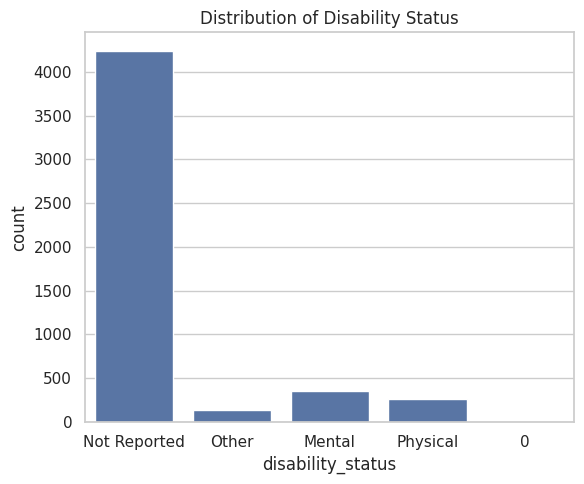

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=employee_df,
    x="disability_status"
)

plt.title("Distribution of Disability Status")

plt.tight_layout()

plt.show()

**Analysis 3 — Correlation Heatmap**

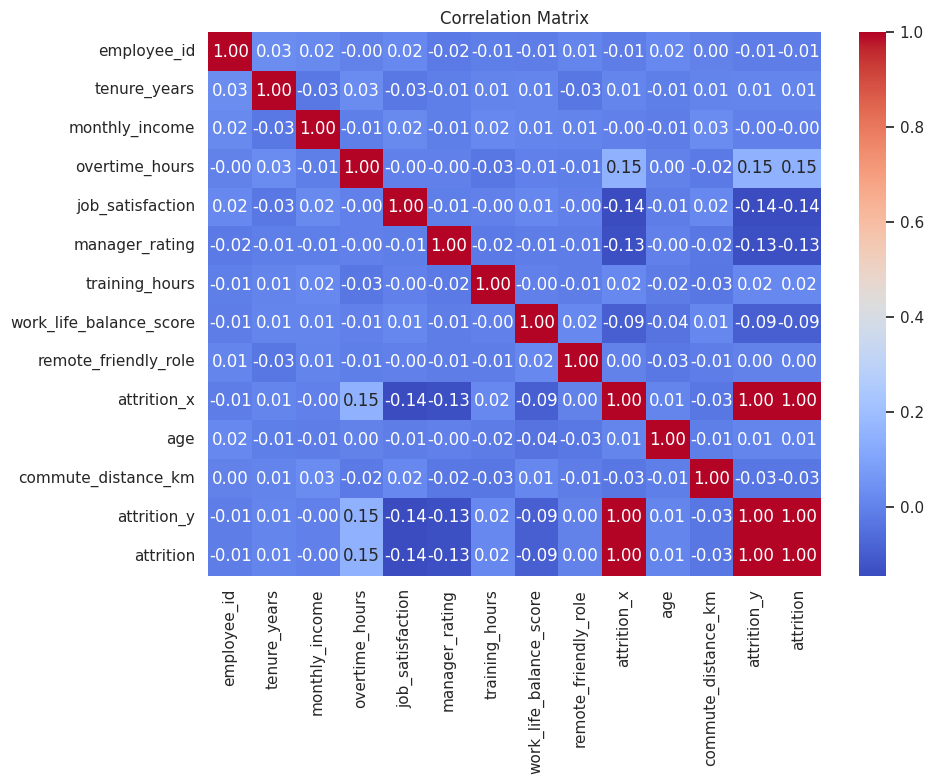

In [ ]:
# ===============================
# Correlation Heatmap
# ===============================

numeric_df = employee_df.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

# Step 5 — Data Preprocessing for Machine Learning

Before training machine learning models, the dataset must be converted into a numerical format.

This includes:

- Separating the target variable (Attrition)
- Encoding categorical variables
- Splitting the dataset into training and testing datasets
- Standardising numerical variables where appropriate

These steps ensure that the predictive models can learn effectively from the employee data.

In [ ]:
# ===============================
# Separate Features and Target
# ===============================

# Attrition is the target variable that the models will predict.
y = employee_df["attrition"]

# Remove all attrition columns from the predictor variables.
# attrition_x and attrition_y contain the actual outcome and
# therefore must not be used as model features.
# employee_id is also removed because it is only an identifier.

X = employee_df.drop(
    columns=["attrition", "attrition_x", "attrition_y", "employee_id"]
)

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nPotential leakage columns:")
print([col for col in X.columns if "attrition" in col.lower()])

Features Shape: (5000, 17)
Target Shape: (5000,)

Target distribution:
attrition
0    2857
1    2143
Name: count, dtype: int64

Potential leakage columns:
[]


**One-Hot Encoding**

In [ ]:
# ===============================
# Convert Categorical Variables
# ===============================

X = pd.get_dummies(X, drop_first=True)

print("Encoded dataset shape:", X.shape)

Encoded dataset shape: (5000, 40)


**Train/Test Split**

In [ ]:
# ===============================
# Train-Test Split
# ===============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)

print("Testing set:", X_test.shape)

Training set: (4000, 40)
Testing set: (1000, 40)


**Feature Scaling**

In [ ]:
# ===============================
# Feature Scaling
# ===============================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Step 6 — Model 1: Logistic Regression

Logistic Regression is selected because:

- It is widely used for binary classification.
- It is easy to interpret.
- HR managers can understand how each variable influences attrition.
- It provides a strong baseline model.

**Train Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

**Predictions**

In [ ]:
log_predictions = log_model.predict(X_test_scaled)

**Accuracy**

In [ ]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(y_test, log_predictions)

print("Logistic Regression Accuracy:", round(log_accuracy,4))

Logistic Regression Accuracy: 0.622


**Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, log_predictions))

              precision    recall  f1-score   support

           0       0.63      0.80      0.71       571
           1       0.59      0.39      0.47       429

    accuracy                           0.62      1000
   macro avg       0.61      0.59      0.59      1000
weighted avg       0.62      0.62      0.60      1000



**Confusion Matrix**

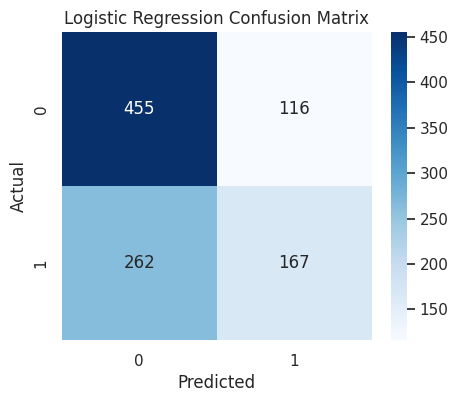

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, log_predictions)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Step 7 — Model 2: Random Forest

Random Forest is selected because:

- It captures complex relationships.
- It is robust to noisy data.
- It handles nonlinear interactions.
- It usually provides strong predictive performance for HR analytics.

**Train Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42,
    n_estimators=200
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

**Predictions**

In [ ]:
rf_predictions = rf_model.predict(X_test)

**Accuracy**

In [ ]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", round(rf_accuracy,4))

Random Forest Accuracy: 0.618


**Classification Report**

In [ ]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.63      0.79      0.70       571
           1       0.58      0.38      0.46       429

    accuracy                           0.62      1000
   macro avg       0.61      0.59      0.58      1000
weighted avg       0.61      0.62      0.60      1000



**Confusion Matrix**

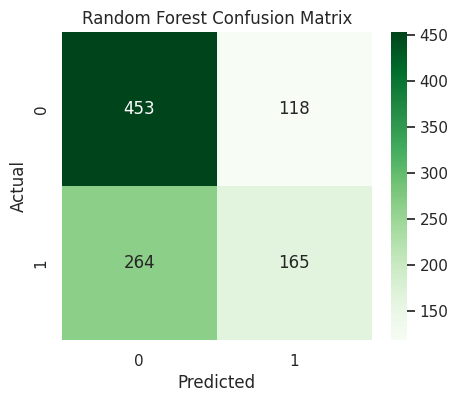

In [ ]:
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(5,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

**Final Model Comparison Table**

In [ ]:
# ===============================
# Model Comparison
# ===============================

comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy":[
        log_accuracy,
        rf_accuracy
    ]
})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy
0,Logistic Regression,0.622
1,Random Forest,0.618


# Best Model

In [ ]:
best_model = comparison.iloc[0]

print("Best Performing Model")

print(best_model)

Best Performing Model
Model       Logistic Regression
Accuracy                  0.622
Name: 0, dtype: object


# Step 8 — ROC Curve & AUC (Better than Accuracy Alone)

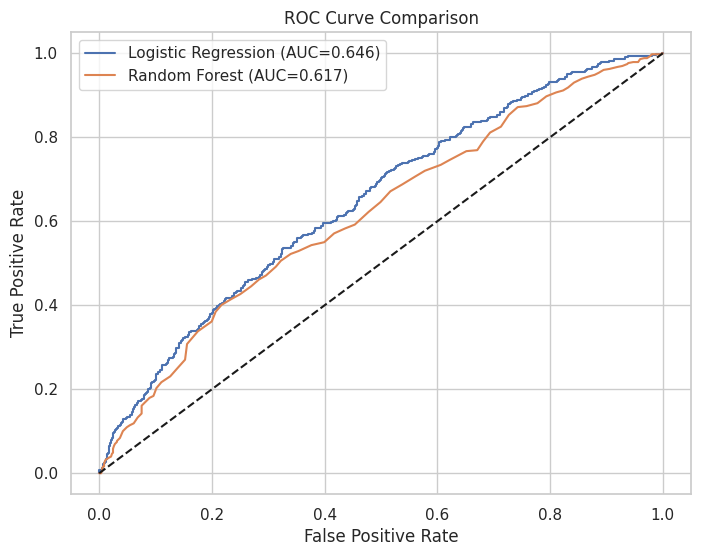

In [ ]:
# ===============================
# ROC Curve
# ===============================

from sklearn.metrics import roc_curve, roc_auc_score

# Probability predictions

log_prob = log_model.predict_proba(X_test_scaled)[:,1]

rf_prob = rf_model.predict_proba(X_test)[:,1]

# Calculate ROC

log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# AUC

log_auc = roc_auc_score(y_test, log_prob)

rf_auc = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(8,6))

plt.plot(log_fpr, log_tpr,
         label=f"Logistic Regression (AUC={log_auc:.3f})")

plt.plot(rf_fpr, rf_tpr,
         label=f"Random Forest (AUC={rf_auc:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

# Step 9 — Feature Importance

In [ ]:
# ===============================
# Feature Importance
# ===============================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
2,overtime_hours,0.111319
0,tenure_years,0.092771
1,monthly_income,0.092699
9,commute_distance_km,0.091157
5,training_hours,0.083996
8,age,0.080227
3,job_satisfaction,0.049456
4,manager_rating,0.048563
6,work_life_balance_score,0.040327
7,remote_friendly_role,0.016894


# Visualisation

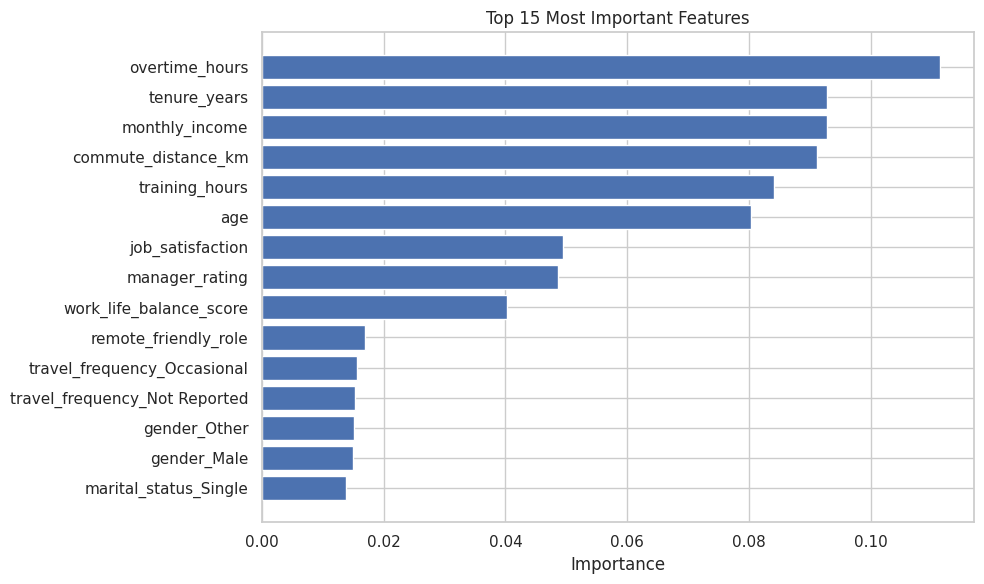

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Most Important Features")

plt.xlabel("Importance")

plt.tight_layout()

plt.show()

# Step 10 — Precision, Recall & F1 Comparison Table

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({

"Model":[
    "Logistic Regression",
    "Random Forest"
],

"Accuracy":[
    accuracy_score(y_test, log_predictions),
    accuracy_score(y_test, rf_predictions)
],

"Precision":[
    precision_score(y_test, log_predictions),
    precision_score(y_test, rf_predictions)
],

"Recall":[
    recall_score(y_test, log_predictions),
    recall_score(y_test, rf_predictions)
],

"F1 Score":[
    f1_score(y_test, log_predictions),
    f1_score(y_test, rf_predictions)
],

"AUC":[
    log_auc,
    rf_auc
]

})

results

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.622,0.590106,0.389277,0.469101,0.645696
1,Random Forest,0.618,0.583039,0.384615,0.463483,0.617230


# Step 11 — Automatically Select Best Model

In [ ]:
best_model = results.sort_values(
    by="F1 Score",
    ascending=False
)

best_model

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,0.622,0.590106,0.389277,0.469101,0.645696
1,Random Forest,0.618,0.583039,0.384615,0.463483,0.617230


# Step 12 — Print Final Recommendation

In [ ]:
print("="*60)

print("MODEL RECOMMENDATION")

print("="*60)

print()

print(best_model.iloc[0])

print()

print("The selected model provides the strongest balance")
print("between prediction accuracy and employee attrition detection.")

MODEL RECOMMENDATION

Model        Logistic Regression
Accuracy                   0.622
Precision               0.590106
Recall                  0.389277
F1 Score                0.469101
AUC                     0.645696
Name: 0, dtype: object

The selected model provides the strongest balance
between prediction accuracy and employee attrition detection.


# Step 13 — Save Clean Dataset

In [ ]:
employee_df.to_csv(
    "clean_employee_data.csv",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


# Step 14 — Save Results Table

In [ ]:
results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


# Explainable AI (XAI) - SHAP


In [ ]:
# Install SHAP if it is not already available in Google Colab
!pip -q install shap

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
# ==========================================
# SHAP Explainability for Logistic Regression
# ==========================================

# Use a representative sample of the test data
X_shap = X_test_scaled[:500]

# Create SHAP explainer for the logistic regression model
explainer = shap.LinearExplainer(
    log_model,
    X_train_scaled
)

# Calculate SHAP values
shap_values = explainer(X_shap)

print("SHAP explanation generated successfully.")
print("SHAP values shape:", shap_values.values.shape)

SHAP explanation generated successfully.
SHAP values shape: (500, 40)


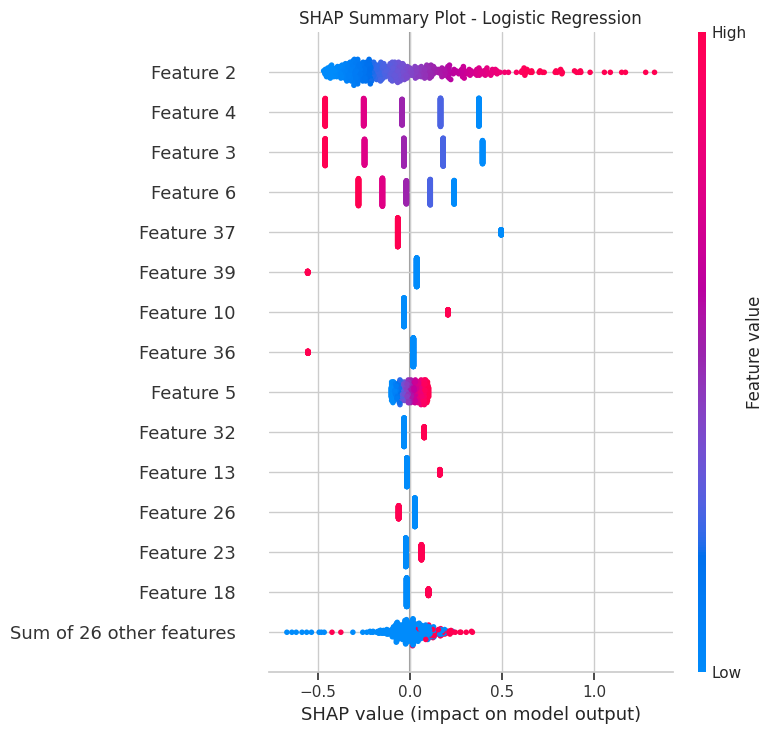

In [ ]:
# ==========================================
# SHAP Summary Plot
# ==========================================

plt.figure(figsize=(10,7))

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title("SHAP Summary Plot - Logistic Regression")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Mean Absolute SHAP Feature Importance
# ==========================================

shap_importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values.values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
)

shap_importance.head(15)

,Feature,Mean_Absolute_SHAP
2,overtime_hours,0.266083
4,manager_rating,0.262206
3,job_satisfaction,0.257396
6,work_life_balance_score,0.162868
37,disability_status_Not Reported,0.133255
39,disability_status_Physical,0.068903
10,job_role_Consultant,0.059550
36,disability_status_Mental,0.053793
5,training_hours,0.051608
32,marital_status_Married,0.044857


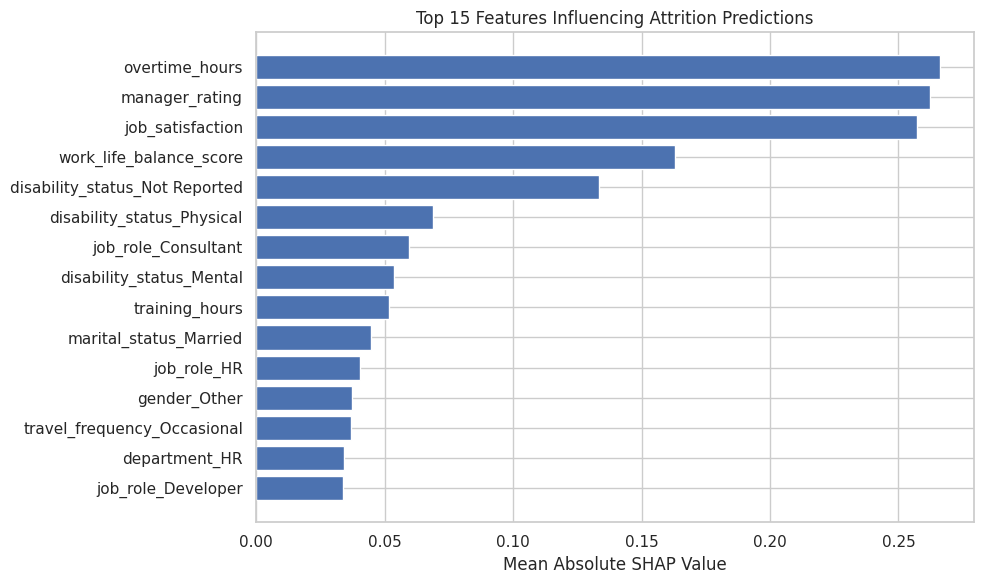

In [ ]:
# ==========================================
# Visualise Top SHAP Features
# ==========================================

top_shap = shap_importance.head(15).sort_values(
    "Mean_Absolute_SHAP"
)

plt.figure(figsize=(10,6))

plt.barh(
    top_shap["Feature"],
    top_shap["Mean_Absolute_SHAP"]
)

plt.title("Top 15 Features Influencing Attrition Predictions")
plt.xlabel("Mean Absolute SHAP Value")

plt.tight_layout()
plt.show()

In [ ]:
print("X columns:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nTarget-related columns remaining in X:")
print([
    col for col in X.columns
    if "attrition" in col.lower()
])

X columns:
['tenure_years', 'monthly_income', 'overtime_hours', 'job_satisfaction', 'manager_rating', 'training_hours', 'work_life_balance_score', 'remote_friendly_role', 'age', 'commute_distance_km', 'job_role_Consultant', 'job_role_Developer', 'job_role_Finance', 'job_role_HR', 'job_role_Manager', 'job_role_Not Reported', 'job_role_Operations', 'department_Finance', 'department_HR', 'department_Not Reported', 'department_Operations', 'department_Technology', 'travel_frequency_Not Reported', 'travel_frequency_Occasional', 'gender_Male', 'gender_Not Reported', 'gender_Other', 'ethnicity_Black', 'ethnicity_Mixed', 'ethnicity_Not Reported', 'ethnicity_Other', 'ethnicity_White', 'marital_status_Married', 'marital_status_Not Reported', 'marital_status_Single', 'marital_status_Widowed', 'disability_status_Mental', 'disability_status_Not Reported', 'disability_status_Other', 'disability_status_Physical']

Target:
attrition

Target-related columns remaining in X:
[]
